<a href="https://colab.research.google.com/github/MtBalbine/PROJETO-1---ESTATISTICA-E-ANALISE-DE-DADOS/blob/main/VarQuantitativaSus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importar as bibliotecas "Pandas" e "Numpy" (Usaremos as abreviações pd e np, respectivamente, para faciliar a notação.
Importe também a biblioteca Math.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Defina a variável "arquivo" pelo nome do arquivo da planilha.
Defina também a variável "coluna". Essa variável definirá qual a variável será considerada para a construção da tabela.

In [3]:
arquivo = 'economia_circular.xlsx'
coluna = 'Indice_Sustentabilidade'

3. Leia a planilha no Phyton (para isso use o comando pd.read_excel(...) ). Dê um nome (nesse caso chamaremos de "df").

In [4]:
df=pd.read_excel(arquivo)
df

,Setor,Porte,Taxa_Circularidade_percent,Indice_Sustentabilidade
0,Têxtil,Pequeno,10.5,24.3
1,Têxtil,Médio,14.0,27.0
2,Alimentos,Pequeno,21.2,27.2
3,Alimentos,Médio,16.0,28.1
4,Eletrônicos,Pequeno,19.9,28.9
...,...,...,...,...
273,Metalurgia,Grande,100.0,86.9
274,Metalurgia,Grande,100.0,87.7
275,Metalurgia,Grande,100.0,88.3
276,Plásticos,Grande,100.0,88.8


4. Montando Tabela de classes, indicando os limites de cada classe (note que a amplitude da classe é a mesma para todas as classes)
Neste caso precisamos antes saber o valor mínimo e o valor máximo dos dados para que todos estejam em pelo menos uma das classes.

In [5]:
valormin=df[coluna].min()
valormax=df[coluna].max()
print (valormin,valormax)

24.3 94.2


Escolhendo os limites e montando a coluna de frequência absoluta.
NOTE QUE PARA A ESCOLHA DOS LIMITES E DA QUANTIDADE DE CLASSES DEVEMOS SEMPRE TER EM MENTE QUE A TABELA É UM RECURSO VISUAL PARA ORGANIZAÇÃO DE DADOS E NESSE CASO NÁO FAZ SENTIDO TER MUITAS LINHAS (PENSEM EM UMA QUANTIDADE DE NO MÁXIMO 10-12 LINHAS).



In [6]:
classes = [20,30,40,50,60,70,80,90,100]
frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia.sort_index(ascending=True)

/tmp/ipykernel_1760/316735622.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Indice_Sustentabilidade,
"[20, 30)",6
"[30, 40)",34
"[40, 50)",81
"[50, 60)",81
"[60, 70)",44
"[70, 80)",22
"[80, 90)",9
"[90, 100)",1


5. Montando Frequência Relativa

In [7]:
Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
Freqpercentual.sort_index(ascending=True)

/tmp/ipykernel_1760/2202019940.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Indice_Sustentabilidade,
"[20, 30)",2.16
"[30, 40)",12.23
"[40, 50)",29.14
"[50, 60)",29.14
"[60, 70)",15.83
"[70, 80)",7.91
"[80, 90)",3.24
"[90, 100)",0.36


6. Montando as colunas da frequência acumulada e da frequência relativa acumulada


In [8]:
#note que é necessário acumular a coluna da frequência com as classes ordenadas, isto é, usando sort_index
freqacum=np.cumsum(frequencia.sort_index())
freqacum




,count
Indice_Sustentabilidade,
"[20, 30)",6
"[30, 40)",40
"[40, 50)",121
"[50, 60)",202
"[60, 70)",246
"[70, 80)",268
"[80, 90)",277
"[90, 100)",278


In [9]:
freqpercacum=np.cumsum(Freqpercentual.sort_index())
freqpercacum

,proportion
Indice_Sustentabilidade,
"[20, 30)",2.16
"[30, 40)",14.39
"[40, 50)",43.53
"[50, 60)",72.67
"[60, 70)",88.50
"[70, 80)",96.41
"[80, 90)",99.65
"[90, 100)",100.01


7. Arrumando a Tabela

In [10]:
dist_freq = pd.DataFrame({'Frequência': frequencia,'Frequência Relativa (%)':Freqpercentual,'Freq.Acum.': freqacum,'Freq.Rel.Acum. (%)':freqpercacum})
print(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

                         Frequência  Frequência Relativa (%)  Freq.Acum.  \
Indice_Sustentabilidade                                                    
[20, 30)                          6                     2.16           6   
[30, 40)                         34                    12.23          40   
[40, 50)                         81                    29.14         121   
[50, 60)                         81                    29.14         202   
[60, 70)                         44                    15.83         246   
[70, 80)                         22                     7.91         268   
[80, 90)                          9                     3.24         277   
[90, 100)                         1                     0.36         278   

                         Freq.Rel.Acum. (%)  
Indice_Sustentabilidade                      
[20, 30)                               2.16  
[30, 40)                              14.39  
[40, 50)                              43.53  
[50, 60) 

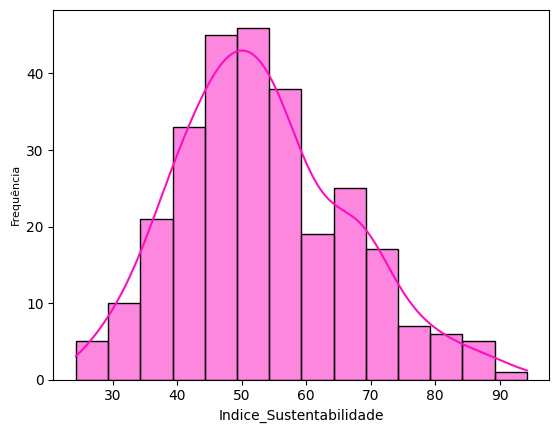

In [11]:
sns.histplot(data=df,x="Indice_Sustentabilidade",kde=True, color="#FC0FC0")
plt.ylabel("Frequência",size=8)
plt.show()

In [12]:
valormin=min(df.Indice_Sustentabilidade)
valormax=max(df.Indice_Sustentabilidade)
valormin,valormax


(24.3, 94.2)

8. Calculo da média, moda e mediana:

In [13]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Idade
df.Indice_Sustentabilidade.mean()

np.float64(53.339928057553955)

In [14]:
# cálculo da moda. Mesmas indicações
df.Indice_Sustentabilidade.mode()

,Indice_Sustentabilidade
0,50.0


In [15]:
#cálculo da mediana.
df.Indice_Sustentabilidade.median()

52.0